# Тема 8. Градиентный бустинг

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Три темы:

1. Важность признаков в XGBoost
2. Подбор нескольких гиперпараметров сразу — `RandomizedSearchCV`
3. Стохастический бустинг: `subsample` как ещё один способ регуляризации

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X = df.drop(columns=["State", "Churn"])
y = df["Churn"]

---
## 1. Важность признаков в XGBoost

Как у дерева и леса — `feature_importances_`, только считается чуть иначе (по умолчанию — через долю участия признака во всех расщеплениях, взвешенную на прирост качества; в отличие от Gini importance дерева/леса из тем 3, 5).

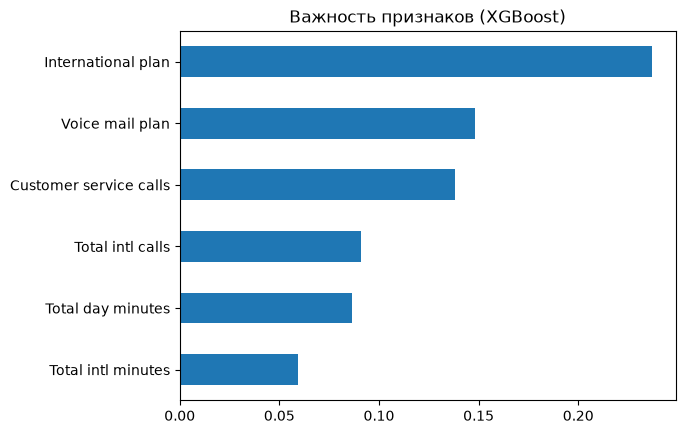

In [3]:
clf = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
clf.fit(X, y)

pd.Series(clf.feature_importances_, index=X.columns).sort_values().tail(6).plot(
    kind="barh", title="Важность признаков (XGBoost)"
);

Снова `International plan` и `Customer service calls` в топе — четвёртая по счёту модель на этом датасете (дерево, лес, XGBoost — плюс коэффициенты логрегрессии из темы 4) подтверждает одно и то же. Когда несколько разных методов сходятся в одном выводе — это куда надёжнее, чем вывод одного метода.

---
## 2. `RandomizedSearchCV`: подбор нескольких параметров сразу

`GridSearchCV` (темы 3, 5) перебирает **все** комбинации параметров — при 4 параметрах с несколькими значениями каждый число комбинаций быстро становится огромным. `RandomizedSearchCV` вместо полного перебора **случайно** пробует `n_iter` комбинаций — почти всегда находит результат, близкий к лучшему, за куда меньшее время.

In [4]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
}
# 3*4*4*3 = 144 комбинаций для полного перебора; переберём случайно только 15
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    param_dist, n_iter=15, cv=skf, random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X, y)
search.best_params_, round(search.best_score_, 4)

({'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1},
 np.float64(0.9568))

15 случайных комбинаций из 144 возможных нашли результат не хуже (иногда лучше) значений, которые мы подбирали на занятии вручную на глаз.

---
## 3. Стохастический бустинг: `subsample`

Ещё один параметр регуляризации, специфичный для бустинга: `subsample` — доля обучающих объектов, которую **случайно** берут для построения каждого отдельного дерева (аналог бутстрапа в лесу, только без возвращения и в куда меньшей степени — обычно 0.5-1.0, а не 100% с повторами). Идея та же, что и с `max_features` у леса: чуть больше случайности в каждом дереве — модель в среднем чуть устойчивее.

In [5]:
for ss in [0.5, 0.7, 0.8, 1.0]:
    model = xgb.XGBClassifier(n_estimators=200, subsample=ss, random_state=RANDOM_STATE, eval_metric="logloss")
    score = cross_val_score(model, X, y, cv=5).mean()
    print(f"subsample={ss}: {score:.4f}")

subsample=0.5: 0.9418


subsample=0.7: 0.9511


subsample=0.8: 0.9526


subsample=1.0: 0.9541


На этом датасете эффект небольшой — `subsample=1.0` (без семплирования) почти не уступает промежуточным значениям. На более шумных и объёмных данных разница обычно заметнее; как и почти всё в этом занятии — параметр стоит попробовать, а не считать само собой разумеющимся, что регуляризация обязательно поможет.

---
## Итог

Это последний ноутбук курса. Дальше — собственные данные, `GridSearchCV`/`RandomizedSearchCV` по всем изученным моделям и, скорее всего, снова эта же последовательность: baseline → интерпретируемая модель → ансамбль.